# Workshop: APIs and prompt engineering

What an **API** is, how the **Google Gemini Python SDK** works (`Client`, `generate_content`, `contents`), and how **prompt engineering** shapes what you get back.

**Goals:**
- Use the **Gemini Python SDK** (`Client`, `generate_content`) to send prompts from Python  
- Explore how **`contents`** (strings and lists of strings) shapes what the model returns  
- Practice **prompt engineering** for tasks like generating `datascience` plotting code  

**Setup:** You need a **Google Gemini API key** from [Google AI Studio](https://aistudio.google.com/apikey). Do not share your key or commit it to git.


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Part 1 — APIs and the Gemini SDK

An **Application Programming Interface (API)** lets programmers use services that other people have written. You often **don’t need to know how something is implemented**—only **what it does** and **how to call it**.

For example, with **NumPy**, when you call `np.average`, you trust that it returns the mean of the values you pass in—you don’t need the implementation details.

In this course you have used **RESTful** APIs (Genius, Wikipedia): you request a **URL** and get structured data back. **Gemini** can be used that way too; here we use Google’s **Python SDK** (`google-genai`): you build a **client** object and call methods like `generate_content`. That pattern is convenient when inputs and outputs are flexible text, and when you make many calls from Python.

**Resources**:

* [Gemini API Quickstart](https://ai.google.dev/gemini-api/docs/quickstart)
* [Google Gen AI Python SDK](https://googleapis.github.io/python-genai/)
* [Gemini API: Prompting Strategies](https://ai.google.dev/gemini-api/docs/prompting-strategies)
* [Ziem et al., Table 1](https://direct.mit.edu/view-large/figure/4722326/coli_a_00502_i004.tif): LLM prompting guidelines (useful for the final project)


## Install and import

Run the cell below to install `google-genai` and import the module.


In [26]:
%pip install google-genai -q
from google import genai


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Gemini API key

Set your key below (or load from `os.environ["GOOGLE_API_KEY"]`). Obtain a key at [Google AI Studio](https://aistudio.google.com/apikey) if needed.

**Do not share your key** or commit it to git.


In [36]:
GOOGLE_API_KEY = "paste your API key here"

## [Tutorial] Chat interface to API


Consider the chat prompt shown in the screenshot, as well as (the start of) the model’s response.

<img src="gemini_page.png" alt="A screenshot of a Google Gemini chat prompt. Prompt is 'Explain how AI works in a few words.'. Response from Gemini chat is long but gets at the idea." width="800">


An **AI chatbot** (like what is shown in the screenshot) is an application *on top of* a **large language model (LLM)**. The **LLM** is what takes in user prompts and returns text responses. The **chatbot** is what filters input, perhaps converting and loading files with additional prompts, and returns filtered LLM responses back, perhaps with some HTML or Markdown formatting.

Let’s break down what is happening in the above screenshot:

* The user **prompt**: "Explain how AI works in a few words."
* The model **response**: "AI works by using algorithms to analyze..."
* The specified **model**: Here, it is "Fast" (note the dropdown in the bottom right). The other option is "Thinking." We’ll discuss model choice more below when we call the API.


### [Tutorial] Create the client then make the request

The structure of making a request:

1. **API client** — `genai.Client(api_key=...)` is your gateway; its methods expose different API calls.
1. **API request** — `client.models.generate_content` takes named arguments:
    * `model`: which LLM (here **Gemini 2.5 Flash**, like the **Fast** option in the web app).
    * `contents`: the **prompt** string.
1. **Response** — `response` is a Gemini-specific object; for this course we mainly use **`response.text`**, the model’s answer as a string.


In [3]:
client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain how AI works in a few words",
)
print(response.text)

AI learns from data to recognize patterns and make intelligent decisions or predictions.


### Run the same request again

You do **not** need to recreate the client. Call `generate_content` again with the same prompt—**LLMs are stochastic**, so the wording may change.


In [28]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain how AI works in a few words",
)
print(response.text)


AI learns patterns from data to make smart decisions.


## Example - restaurant suggestions

We pass in a different **string** for `contents`. Run the cell below as-is, then try editing the prompt (different city, budget, cuisine, etc.).


In [5]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="What is the best restaurant in Auburn, Alabama? Give one recommendation and a short reason in bulleted format.",
)
restaurant_str = response.text
print(restaurant_str)

The "best" restaurant can be subjective, but considering culinary reputation, dining experience, and innovation, one consistently stands out:

*   **Acre**
    *   **Inventive Southern Cuisine:** Known for its refined, seasonal menu with a strong emphasis on locally sourced, farm-to-table ingredients.
    *   **Acclaimed Chef:** Led by Chef David Bancroft, who has garnered multiple James Beard Award nominations.
    *   **Elegant Atmosphere:** Offers a sophisticated yet comfortable dining experience, perfect for a special occasion or an elevated meal.


<hr style="border: 1px solid #fdb515;" />


## Different Gemini models (optional)

- **`gemini-2.5-flash`** — fast; use this while iterating on prompts.
- **`gemini-2.5-pro`** — often richer answers; **slower and costlier**.

**Discuss:** If you try both on the same prompt, what differs in length, tone, or specificity?


**Tip:** Prefer **Gemini 2.5 Flash** while iterating on prompts. **Pro** is slower and costlier; switch only when your prompt is working.


In [7]:
# Optional: same prompt with Pro (may take ~30–90 seconds)
response_pro = client.models.generate_content(
    model="gemini-2.5-pro",
    contents= "What is the best restaurant in Auburn, Alabama? Give one recommendation and a short reason in bulleted format.",  # reuse the same prompt as above
)
print(response_pro.text)

**Acre**

*   Led by a James Beard Award-nominated chef, Acre serves inventive, upscale Southern cuisine with many ingredients sourced directly from its on-site garden and local farms.


<hr style="border: 1px solid #fdb515;" />

# Part 2 - Prompt Engineering

# [Tutorial] Providing more context for prompts
In `client.models.generate_content`, the `model` argument is a **string**, `contents` in the examples so far is a **string**, and **`response.text`** is a **string**. When you pass several context pieces later, `contents` can be a **list of strings**.

From [Wikipedia](https://en.wikipedia.org/wiki/Prompt_engineering): **Prompt engineering** is the process of structuring or crafting a **prompt** (natural language instruction) in order to produce better outputs from a generative AI model.

Depending on how you wrote your prompts above, you may find that responses were too general. 

A common approach is to add **context**: constraints, tone, length, format (bullets, JSON), audience, and line breaks between sections.

<details>
<summary><b>Expand for an example: pass the prompt as a multiline string (<code>"""…"""</code>) in <code>contents</code></b></summary>

This cell uses a **multiline string** (`"""..."""`) unlike the code cell below that uses **list** in contents.


```python
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="""Imagine you are a UC Berkeley student talking to a fellow classmate.
    
    What is the best restaurant in Berkeley? Only include cheap meals under $15,
    and only consider restaurants that are open past 9pm.

    Format your response as a bulleted list. Limit your response to 200 words.
    """
)
```

print(response.text)
</details>

## Lists of strings for `contents`

The Gemini API accepts several types for `contents`. Here we pass a **list of strings** so you can **reuse** persona and format snippets across prompts.


In [8]:
context_character = "Imagine you are an exceptinal tour guide who is a local expert talking to a fellow friend."
context_format = "Format your response as a bulleted list and make sure each sentence starts in a new line. Limit your response to 200 words."

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        context_character,
        (
            "What is the best restaurant in Auburn, Alabama? Only include cheap meals under $15, "
            "and only consider restaurants that are open past 9pm."
        ),
        context_format,
    ],
)
print(response.text)

Hey friend! You're asking about the *best* late-night, cheap eats in Auburn, and I’ve got you covered.

*   Without a doubt, for awesome food that won't break the bank and is open late, you absolutely have to hit up **Momma Goldberg's Deli** downtown.
*   This place is an absolute Auburn institution, a true classic.
*   Their famous "Steamer" sandwich is legendary and you can't leave without trying one.
*   It's a hot, gooey, delicious masterpiece piled high with ham, turkey, provolone, and Monterey Jack, all steamed to perfection.
*   Seriously, it’s under $10 and incredibly satisfying.
*   They’re typically open until at least 10 PM, often later on weekends, perfect for a late dinner or post-game snack.
*   Plus, the atmosphere is exactly what you expect from a beloved college town spot.
*   It’s casual, lively, and just plain good food.
*   Trust me on this one, you’ll thank me after your first bite.
*   It’s the perfect blend of local flavor, affordability, and late-night convenien

In [ ]:
context_character = "Imagine you are an exceptinal tour guide who is a local expert talking to a fellow friend."
context_format = "Format your response as a bulleted list and make sure each sentence starts in a new line. Limit your response to 200 words."

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        context_character,
        (
            "What is the best restaurant in Auburn, Alabama? Only include cheap meals under $15, "
            "and only consider restaurants that are open past 9pm."
        ),
        context_format,
    ],
)
print(response.text)

Hey friend! You're asking about the *best* late-night, cheap eats in Auburn, and I’ve got you covered.

*   Without a doubt, for awesome food that won't break the bank and is open late, you absolutely have to hit up **Momma Goldberg's Deli** downtown.
*   This place is an absolute Auburn institution, a true classic.
*   Their famous "Steamer" sandwich is legendary and you can't leave without trying one.
*   It's a hot, gooey, delicious masterpiece piled high with ham, turkey, provolone, and Monterey Jack, all steamed to perfection.
*   Seriously, it’s under $10 and incredibly satisfying.
*   They’re typically open until at least 10 PM, often later on weekends, perfect for a late dinner or post-game snack.
*   Plus, the atmosphere is exactly what you expect from a beloved college town spot.
*   It’s casual, lively, and just plain good food.
*   Trust me on this one, you’ll thank me after your first bite.
*   It’s the perfect blend of local flavor, affordability, and late-night convenien

<hr style="border: 1px solid #fdb515;" />

## Prompt Engineering: Check your understanding

## Your turn — LLM writes plotting code

In Workshop 2: Visualization, you created a `num_applicant` table that shows the application counts for males and females in each department using `cal_data`, which stores the dataset from the `'UCBerkeley1973_Admission.csv'`. Then you used `num_applicant` to create a bar chart visualization below using `num_applicant.bar("Major")`:

<img src="https://github.com/dubois-ctds/data6-nwdse-2025/blob/main/visualizations-workshop/barchart.png?raw=true" alt="Bar Chart"/>

Please run the following two cells below to import the necessary libraries that allows the code to correctly output the bar chart and we have included `cal_data` table for reference: 

In [29]:
# Run this cell.
from datascience import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")
import warnings
warnings.filterwarnings('ignore')

In [30]:
cal_data = Table.read_table('UCBerkeley1973_Admission.csv')
cal_data.show(5)

Year,Major,Gender,Admission
1973,C,F,Rejected
1973,B,M,Accepted
1973,Other,F,Accepted
1973,Other,M,Accepted
1973,Other,M,Rejected


Now you will be asking Gemini to write a complete Python function called `num_applicant_bar(cal_data)` that reproduces the bar chart above from **Simpson’s paradox** style admissions data, by making sure that your **prompt includes the following**:

- Clearly state the function name and its input parameter(s).
- Specify what the function should display or return (e.g., an overlaid bar chart).
- Mention the dataset columns relevant for the plot (e.g., gender, major).
- Indicate the use of overlaid bars (not stacked) with a bar chart.
- Be explicit about using the datascience Table API.

- **Model:** Please use `gemini-2.5-flash`

**TASK:** **Please replace `...` with your **prompt string** and **model string**.**

**NOTE**: we have included necessary contexts into the list of `contents` already to ensure that the LLM model can produce the exact plot from Workshop 2.

In [12]:
preview = str(cal_data.take(5))  #preview of the cal_data table 
context_dataset = "The table cal_data has columns Year, Major, Gender (F or M), Admission (Accepted or Rejected) and the data is loaded in for you"
context_imports = "You can only use the datascience library"
context_code_structure = "Do not include any other text than the function definition. Do not include texts like comments, etc."
context_function_steps = (
    "Count applicants per Gender × Major with pivot (or group then pivot with values=count), "
    "Relabel columns F and M to F Application Count and M Application Count (exact strings), "
    "Plot with table.bar(Major, overlay=True) so bars are overlaid, not stacked"
)
context_barchart_components = "Make sure that the x-axis is Major and the legend is F Application Count and M Application Count"
context_function_output = "The function should return the overlaid bar chart and another line that passes in cal_data to the function"

response = client.models.generate_content(
    model= "gemini-2.5-flash",
    contents=[
        f"Sample rows (for context only):\n{preview}",
        context_dataset,
        context_imports,
        (
            'Generate a function called num_applicant_bar(cal_data) that takes a table and displays an overlaid bar chart of the number of applicants by gender and major'
        ),
        context_barchart_components,
        context_code_structure,
        context_function_steps,
        context_function_output,
    ],
)
print(response.text)

```python
from datascience import Table

def num_applicant_bar(cal_data):
    applicant_counts = cal_data.pivot('Gender', 'Major')
    applicant_counts = applicant_counts.relabeled('F', 'F Application Count')
    applicant_counts = applicant_counts.relabeled('M', 'M Application Count')
    return applicant_counts.bar('Major', overlay=True)

num_applicant_bar(cal_data)
```


**Test the model’s code:** paste the function `` into the cell below (or edit that cell until it runs), then run it.

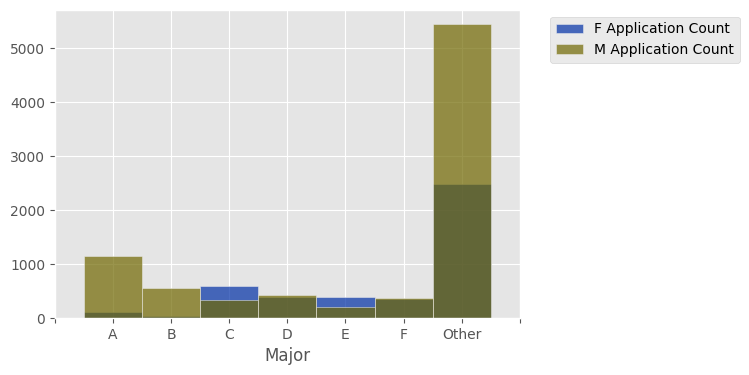

In [13]:

def num_applicant_bar(cal_data):
    applicant_counts = cal_data.pivot('Gender', 'Major')
    applicant_counts = applicant_counts.relabeled('F', 'F Application Count')
    applicant_counts = applicant_counts.relabeled('M', 'M Application Count')
    return applicant_counts.bar('Major', overlay=True)

num_applicant_bar(cal_data)

**Compare** the model's code with your code from Workshop 2 below:

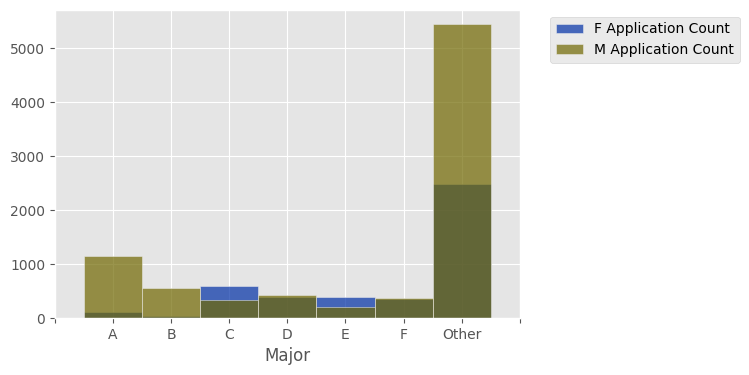

In [42]:
num_applicants = cal_data.group(['Major', 'Gender']).pivot('Gender', 'Major', collect=np.sum, values='count')
num_applicants = num_applicants.relabeled(['F', 'M'], ['F Application Count', 'M Application Count'])
num_applicants.bar("Major")

## Hallucination and why context fixed it here

**Hallucination** is when the model generates plausible-looking output that is not faithful to the task requirements.

In this activity, hallucination can look like:
- using libraries other than `datascience`
- returning the wrong function name/signature
- using different column labels (not exactly `F Application Count` and `M Application Count`)
- making a stacked chart instead of an overlaid chart
- adding extra explanation text instead of only code

After adding explicit context in the prompt (dataset schema, allowed library, exact function name, exact relabel strings, chart type, and output format constraints), Gemini is much less likely to hallucinate because the solution space is tightly bounded.

So the key lesson is: we did not "make the model smarter"; we made the task specification precise enough that the model can follow it reliably.

In [34]:
# Example prompt with weak constraints (more likely to hallucinate)

preview = str(cal_data.take(5))

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        f"Sample rows (for context only):\n{preview}",
        "Write Python code to make a bar chart of applicants by major and gender.",
        "Use the provided table variable cal_data.",
        "Use any approach you think is best.",
        "Include code only.",
    ],
)

print(response.text)

```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume cal_data is a pandas DataFrame that has been loaded.
# For demonstration purposes, we'll create a sample cal_data
# based on the provided structure and add more rows for a meaningful chart:
sample_data = {
    'Year': [1973, 1973, 1973, 1973, 1973, 1973, 1974, 1974, 1974, 1974, 1974, 1975, 1975, 1975, 1975],
    'Major': ['Other', 'Math', 'Physics', 'Math', 'Other', 'Chemistry', 'Math', 'Physics', 'Other', 'Chemistry', 'Physics', 'Math', 'Other', 'Physics', 'Chemistry'],
    'Gender': ['M', 'F', 'M', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'Admission': ['Rejected', 'Admitted', 'Admitted', 'Rejected', 'Admitted', 'Rejected', 'Admitted', 'Rejected', 'Admitted', 'Admitted', 'Rejected', 'Admitted', 'Rejected', 'Admitted', 'Rejected']
}
cal_data = pd.DataFrame(sample_data)

# Create the bar chart of applicants by major and gender
plt.figure(figsize=(10, 6))
sns.countplot(da

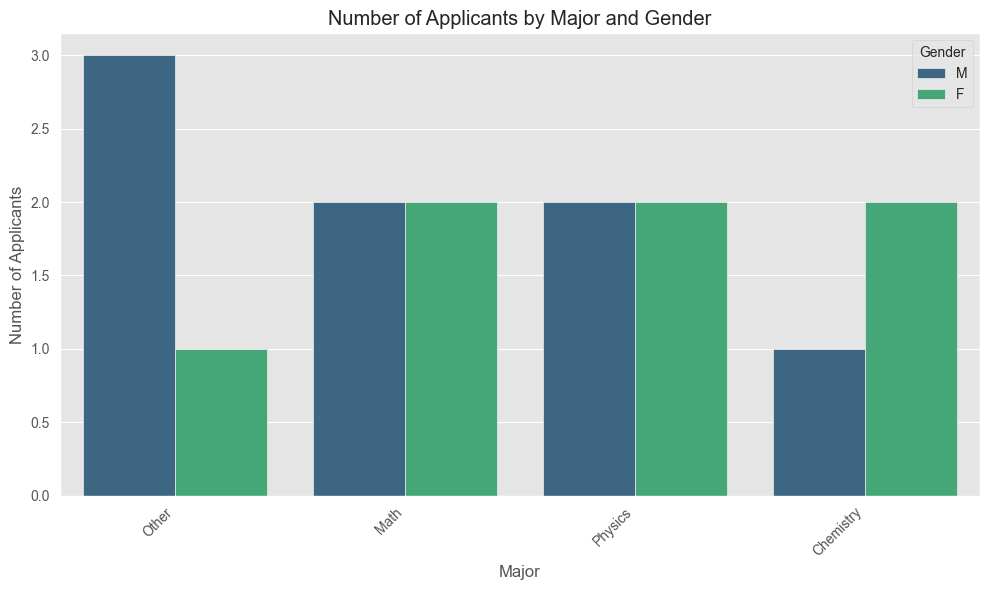

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume cal_data is a pandas DataFrame that has been loaded.
# For demonstration purposes, we'll create a sample cal_data
# based on the provided structure and add more rows for a meaningful chart:
sample_data = {
    'Year': [1973, 1973, 1973, 1973, 1973, 1973, 1974, 1974, 1974, 1974, 1974, 1975, 1975, 1975, 1975],
    'Major': ['Other', 'Math', 'Physics', 'Math', 'Other', 'Chemistry', 'Math', 'Physics', 'Other', 'Chemistry', 'Physics', 'Math', 'Other', 'Physics', 'Chemistry'],
    'Gender': ['M', 'F', 'M', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'Admission': ['Rejected', 'Admitted', 'Admitted', 'Rejected', 'Admitted', 'Rejected', 'Admitted', 'Rejected', 'Admitted', 'Admitted', 'Rejected', 'Admitted', 'Rejected', 'Admitted', 'Rejected']
}
cal_data = pd.DataFrame(sample_data)

# Create the bar chart of applicants by major and gender
plt.figure(figsize=(10, 6))
sns.countplot(data=cal_data, x='Major', hue='Gender', palette='viridis')

# Add title and labels for clarity
plt.title('Number of Applicants by Major and Gender')
plt.xlabel('Major')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlap
plt.legend(title='Gender')
plt.tight_layout() # Adjust layout to prevent elements from overlapping
plt.show()

## Prompt engineering resources

* [Gemini API: Prompting Strategies](https://ai.google.dev/gemini-api/docs/prompting-strategies)
* [Ziem et al., Table 1](https://direct.mit.edu/view-large/figure/4722326/coli_a_00502_i004.tif)


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />
